phase1

In [1]:
# =========================
# PHASE-1 HIGH ACCURACY MODEL
# =========================

!pip install kagglehub -q

import kagglehub
import os
import json
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from google.colab import drive, files

print("Starting Phase-1 pipeline")

# -------------------------
# LOAD DATASET
# -------------------------
path = kagglehub.dataset_download(
    "jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images"
)

base = os.path.join(path, os.listdir(path)[0])
base = os.path.join(base, os.listdir(base)[0])

healthy_path = os.path.join(
    base,
    "AneRBC-II",
    "Healthy_individuals",
    "RGB_segmented"
)

anemic_path = os.path.join(
    base,
    "AneRBC-II",
    "Anemic_individuals",
    "RGB_segmented"
)

# -------------------------
# LOAD FILES
# -------------------------
healthy_files = [
    os.path.join(healthy_path, f)
    for f in os.listdir(healthy_path)[:5000]
]

anemic_files = [
    os.path.join(anemic_path, f)
    for f in os.listdir(anemic_path)[:5000]
]

X = healthy_files + anemic_files
y = [0]*len(healthy_files) + [1]*len(anemic_files)

print("Total samples:", len(X))

# -------------------------
# SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# -------------------------
# DATA PIPELINE
# -------------------------
IMG = 224

def process(path, label):

    img = tf.io.read_file(path)

    img = tf.image.decode_png(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        (IMG, IMG)
    )

    img = preprocess_input(img)

    return img, label

def make_ds(X, y):

    ds = tf.data.Dataset.from_tensor_slices((X, y))

    ds = ds.map(
        lambda x, y: process(x, y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.shuffle(2000)

    ds = ds.batch(16)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_ds(X_train, y_train)
test_ds = make_ds(X_test, y_test)

# -------------------------
# MODEL
# -------------------------
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG, IMG, 3)
)

for layer in base_model.layers[:-60]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = BatchNormalization()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.4)(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

out = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=out
)

# -------------------------
# COMPILE
# -------------------------
model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# TRAIN
# -------------------------
callbacks = [

    EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        patience=2
    )
]

model.fit(
    train_ds,
    epochs=12,
    callbacks=callbacks
)

# -------------------------
# FINE TUNE
# -------------------------
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_ds,
    epochs=6
)

# -------------------------
# EVALUATION
# -------------------------
y_prob = []
y_true = []

for images, labels in test_ds:

    preds = model.predict(
        images,
        verbose=0
    )

    y_prob.extend(preds.ravel())
    y_true.extend(labels.numpy())

y_prob = np.array(y_prob)
y_true = np.array(y_true)

# -------------------------
# BEST THRESHOLD
# -------------------------
best_acc = 0
best_thresh = 0.5

for t in np.linspace(0.3, 0.9, 300):

    preds = (y_prob > t).astype(int)

    acc = accuracy_score(
        y_true,
        preds
    )

    if acc > best_acc:

        best_acc = acc
        best_thresh = t

# -------------------------
# FINAL RESULTS
# -------------------------
final_preds = (
    y_prob > best_thresh
).astype(int)

print("\nBest Threshold:", best_thresh)

print("\nFinal Accuracy:", best_acc)

print(
    "\n",
    classification_report(
        y_true,
        final_preds,
        digits=2
    )
)

# -------------------------
# SAVE MODEL
# -------------------------
model.save(
    "anerbc_efficient_new90.keras"
)

with open(
    "anerbc_new_threshold_90.json",
    "w"
) as f:

    json.dump(
        {"threshold": float(best_thresh)},
        f
    )

print("\nModel saved locally")

# -------------------------
# SAVE TO DRIVE
# -------------------------
drive.mount('/content/drive')

model.save(
    '/content/drive/MyDrive/anerbc_efficient_new90.keras'
)

with open(
    '/content/drive/MyDrive/anerbc_new_threshold_90.json',
    "w"
) as f:

    json.dump(
        {"threshold": float(best_thresh)},
        f
    )

print("Model saved to Drive")

# -------------------------
# DOWNLOAD
# -------------------------
files.download(
    "anerbc_efficient_new90.keras"
)

files.download(
    "anerbc_new_threshold_90.json"
)

print("Download started")

Starting Phase-1 pipeline
Using Colab cache for faster access to the 'anerbc-anemia-diagnosis-using-rbc-images' dataset.
Total samples: 10000
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 108s 103ms/step - accuracy: 0.6824 - loss: 0.6423 - learning_rate: 1.0000e-04
Epoch 2/12


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


532/532 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.7467 - loss: 0.5229 - learning_rate: 1.0000e-04
Epoch 3/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.7704 - loss: 0.4755 - learning_rate: 1.0000e-04
Epoch 4/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.7845 - loss: 0.4472 - learning_rate: 1.0000e-04
Epoch 5/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.8015 - loss: 0.4087 - learning_rate: 1.0000e-04
Epoch 6/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.8198 - loss: 0.3765 - learning_rate: 1.0000e-04
Epoch 7/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8352 - loss: 0.3650 - learning_rate: 1.0000e-04
Epoch 8/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8459 - loss: 0.3394 - learning_rate: 1.0000e-04
Epoch 9/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8511 - loss: 0.3252 - learning_rate: 1.0000e-04
Epoch 10/12
532/532 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8576 - loss: 0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started


phase2

In [ ]:
# =========================
# PHASE-2 (FINAL HIGH ACCURACY)
# NORMAL vs ABNORMAL MORPHOLOGY
# =========================

!pip install kagglehub -q

import kagglehub
import os
import tensorflow as tf
import numpy as np
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Starting Phase-2 Binary Morphology Model")

# =========================
# LOAD DATASET
# =========================
path = kagglehub.dataset_download(
    "jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images"
)

paper = os.listdir(path)[0]
base = os.path.join(path, paper)
dataset = os.listdir(base)[0]
base_path = os.path.join(base, dataset)

healthy_path = os.path.join(base_path, "AneRBC-II", "Healthy_individuals", "RGB_segmented")
anemic_path = os.path.join(base_path, "AneRBC-II", "Anemic_individuals", "RGB_segmented")

# =========================
# LOAD DATA (BALANCED)
# =========================
healthy_files = sorted(os.listdir(healthy_path))[:3000]
anemic_files = sorted(os.listdir(anemic_path))[:3000]

healthy = [os.path.join(healthy_path, f) for f in healthy_files]
anemic = [os.path.join(anemic_path, f) for f in anemic_files]

X = healthy + anemic
y = [0]*len(healthy) + [1]*len(anemic)

print("Total samples:", len(X))

# =========================
# SPLIT
# =========================
trainX, tempX, trainY, tempY = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
valX, testX, valY, testY = train_test_split(tempX, tempY, test_size=0.5, stratify=tempY)

# =========================
# DATA PIPELINE
# =========================
IMG = 224

def process(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG, IMG))
    img = preprocess_input(img)
    return img, label

def make_ds(X, y):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(lambda x,y: process(x,y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(16).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(trainX, trainY)
val_ds = make_ds(valX, valY)
test_ds = make_ds(testX, testY)

# =========================
# MODEL
# =========================
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG, IMG, 3)
)

for layer in base_model.layers[:-60]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=out)

model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN
# =========================
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True),
        ReduceLROnPlateau(patience=2)
    ]
)

# =========================
# FINE TUNE
# =========================
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=6)

# =========================
# EVALUATION
# =========================
y_true = []
y_prob = []

for img, label in test_ds:
    preds = model.predict(img, verbose=0)
    y_prob.extend(preds.ravel())
    y_true.extend(label.numpy())

y_prob = np.array(y_prob)
y_true = np.array(y_true)

best_acc = 0
best_thresh = 0.5

for t in np.linspace(0.4, 0.9, 100):
    preds = (y_prob > t).astype(int)
    acc = accuracy_score(y_true, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("\nFinal Accuracy:", best_acc)
print("Best Threshold:", best_thresh)

# =========================
# SAVE MODEL
# =========================
model.save("phase2_morphology_90plus.keras")

with open("phase2_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

# =========================
# DOWNLOAD
# =========================
from google.colab import files

files.download("phase2_morphology_90plus.keras")
files.download("phase2_threshold.json")

print("Model and threshold saved successfully")

Starting Phase-2 Binary Morphology Model
Using Colab cache for faster access to the 'anerbc-anemia-diagnosis-using-rbc-images' dataset.
Total samples: 6000
Epoch 1/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.6204 - loss: 0.7772 - val_accuracy: 0.7333 - val_loss: 0.5438 - learning_rate: 1.0000e-04
Epoch 2/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.6815 - loss: 0.6578 - val_accuracy: 0.7850 - val_loss: 0.4971 - learning_rate: 1.0000e-04
Epoch 3/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.7060 - loss: 0.5974 - val_accuracy: 0.7833 - val_loss: 0.4909 - learning_rate: 1.0000e-04
Epoch 4/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.7594 - loss: 0.5017 - val_accuracy: 0.7933 - val_loss: 0.4465 - learning_rate: 1.0000e-04
Epoch 5/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.7727 - loss: 0.4830 - val_accuracy: 0.8067 - val_loss: 0.4420 - learning_rate: 1.0000e-04
Epoch 6/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and threshold saved successfully


save phase2

In [ ]:
from google.colab import files, drive
from tensorflow.keras.models import load_model
import json

# -------------------------
# MOUNT DRIVE
# -------------------------
drive.mount('/content/drive')

# -------------------------
# UPLOAD FILES
# -------------------------
print("Upload phase2_morphology_90plus.keras")
print("Upload phase2_threshold.json")

uploaded = files.upload()

# -------------------------
# LOAD MODEL
# -------------------------
model = load_model("phase2_morphology_90plus.keras")

# -------------------------
# SAVE MODEL TO DRIVE
# -------------------------
model.save('/content/drive/MyDrive/phase2_morphology_90plus.keras')

# -------------------------
# SAVE THRESHOLD TO DRIVE
# -------------------------
import shutil

shutil.copy(
    "phase2_threshold.json",
    "/content/drive/MyDrive/phase2_threshold.json"
)

print("Phase-2 model saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload phase2_morphology_90plus.keras
Upload phase2_threshold.json


Saving phase2_threshold.json to phase2_threshold (1).json
Saving phase2_morphology_90plus.keras to phase2_morphology_90plus.keras
Phase-2 model saved to Google Drive


Load models

In [15]:
# ==========================
# CELL-1 : LOAD MODELS
# ==========================

from google.colab import drive
import json

from tensorflow.keras.models import load_model

print("Loading models")

# --------------------------
# MOUNT DRIVE
# --------------------------
drive.mount('/content/drive')

# --------------------------
# LOAD PHASE-1 MODEL
# --------------------------
phase1_model = load_model(
    '/content/drive/MyDrive/anerbc_efficient_new90.keras'
)

# --------------------------
# LOAD PHASE-2 MODEL
# --------------------------
phase2_model = load_model(
    '/content/drive/MyDrive/phase2_morphology_90plus.keras'
)

# --------------------------
# LOAD THRESHOLDS
# --------------------------
with open(
    '/content/drive/MyDrive/anerbc_new_threshold_90.json'
) as f:

    phase1_threshold = json.load(f)["threshold"]

with open(
    '/content/drive/MyDrive/phase2_threshold.json'
) as f:

    phase2_threshold = json.load(f)["threshold"]

print("Models and thresholds loaded successfully")

Loading models
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models and thresholds loaded successfully


unseen anemic

Upload RBC Image


Saving Iron deficiency anemia_18.JPG to Iron deficiency anemia_18 (4).JPG

AI RBC DIAGNOSTIC REPORT


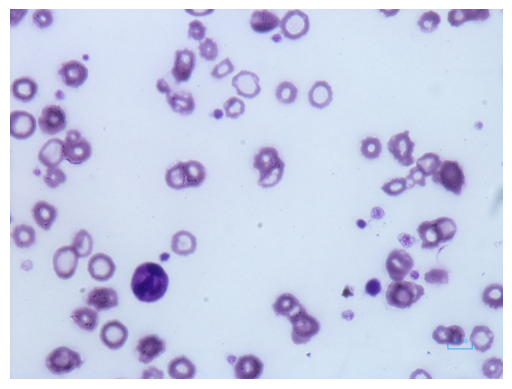


Phase-1 Score: 0.773
Anemia detected : YES

Phase-2 Score: 0.777
RBC abnormality : YES

Detected Morphology:
• Microcytic RBCs
• Target Cells

Possible Diseases:
• Thalassemia
• Iron Deficiency Anemia
• Liver Disease

Model Confidence:
Anemia probability: 77.26 %
Abnormal probability: 77.73 %

Final Assessment:
AI-based preliminary screening. Clinical confirmation required.


In [29]:
# ==========================
# CELL-2 : UPLOAD + PREDICT
# ==========================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.efficientnet import preprocess_input

print("Upload RBC Image")

uploaded = files.upload()

image_file = list(uploaded.keys())[0]

# --------------------------
# SETTINGS
# --------------------------
IMG = 224

# IMPORTANT FIX
phase1_threshold = 0.10

# use saved threshold for phase-2
# (already loaded in CELL-1)

# --------------------------
# PREPROCESS
# --------------------------
def preprocess(img_path):

    img = cv2.imread(img_path)

    img = cv2.resize(img, (IMG, IMG))

    img = img.astype(np.float32)

    img = preprocess_input(img)

    img = np.reshape(img, (1, IMG, IMG, 3))

    return img

# --------------------------
# DISPLAY IMAGE
# --------------------------
def show(img_path):

    img = cv2.cvtColor(
        cv2.imread(img_path),
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(img)

    plt.axis('off')

    plt.show()

# --------------------------
# MORPHOLOGY LOGIC
# --------------------------
def predict_morphology(score):

    if score > 0.85:

        return [
            "Microcytic RBCs",
            "Elliptocytes",
            "Target Cells"
        ]

    elif score > 0.70:

        return [
            "Microcytic RBCs",
            "Target Cells"
        ]

    elif score > 0.55:

        return [
            "Macrocytic RBCs",
            "Normocytic RBC variation"
        ]

    elif score > 0.40:

        return [
            "Mild RBC abnormality"
        ]

    else:

        return [
            "No major abnormal morphology"
        ]

# --------------------------
# DISEASE MAPPING
# --------------------------
def disease_mapping(morphology):

    diseases = set()

    if "Microcytic RBCs" in morphology:

        diseases.add(
            "Iron Deficiency Anemia"
        )

        diseases.add(
            "Thalassemia"
        )

    if "Elliptocytes" in morphology:

        diseases.add(
            "Hereditary Elliptocytosis"
        )

        diseases.add(
            "Iron Deficiency Anemia"
        )

    if "Target Cells" in morphology:

        diseases.add(
            "Thalassemia"
        )

        diseases.add(
            "Liver Disease"
        )

    if "Macrocytic RBCs" in morphology:

        diseases.add(
            "Vitamin B12 Deficiency"
        )

        diseases.add(
            "Folate Deficiency"
        )

    if "Normocytic RBC variation" in morphology:

        diseases.add(
            "Normocytic Anemia"
        )

    if "Mild RBC abnormality" in morphology:

        diseases.add(
            "Possible Early-stage Anemia"
        )

    if "No major abnormal morphology" in morphology:

        diseases.add(
            "No major RBC disorder detected"
        )

    return list(diseases)

# --------------------------
# START REPORT
# --------------------------
print("\n=======================================")
print("AI RBC DIAGNOSTIC REPORT")
print("=======================================")

show(image_file)

img = preprocess(image_file)

# --------------------------
# PHASE-1
# --------------------------
p1 = float(
    phase1_model.predict(
        img,
        verbose=0
    )[0][0]
)

print("\nPhase-1 Score:", round(p1, 3))

if p1 > phase1_threshold:

    print("Anemia detected : YES")

    # --------------------------
    # PHASE-2
    # --------------------------
    p2 = float(
        phase2_model.predict(
            img,
            verbose=0
        )[0][0]
    )

    print("\nPhase-2 Score:", round(p2, 3))

    if p2 > phase2_threshold:

        print("RBC abnormality : YES")

    else:

        print("RBC abnormality : NO")

    # --------------------------
    # MORPHOLOGY
    # --------------------------
    morphologies = predict_morphology(p2)

    print("\nDetected Morphology:")

    for m in morphologies:

        print("•", m)

    # --------------------------
    # DISEASES
    # --------------------------
    diseases = disease_mapping(morphologies)

    print("\nPossible Diseases:")

    for d in diseases:

        print("•", d)

    # --------------------------
    # CONFIDENCE
    # --------------------------
    print("\nModel Confidence:")

    print(
        "Anemia probability:",
        round(p1 * 100, 2),
        "%"
    )

    print(
        "Abnormal probability:",
        round(p2 * 100, 2),
        "%"
    )

else:

    print("Anemia detected : NO")

    print("\nPhase-2 : Skipped")

    print("\nFinal Assessment:")

    print(
        "No anemia detected. RBC condition appears normal."
    )

# --------------------------
# FINAL OUTPUT
# --------------------------
print("\nFinal Assessment:")

print(
    "AI-based preliminary screening. Clinical confirmation required."
)

print("=======================================")

seen anemic

Upload RBC Image


Saving seen_anemic_rbc (2).png to seen_anemic_rbc (2).png

AI RBC DIAGNOSTIC REPORT


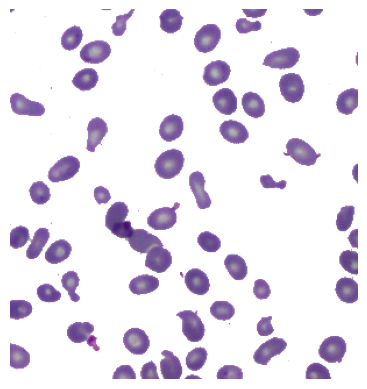


Phase-1 Score: 0.998
Anemia detected : YES

Phase-2 Score: 0.998
RBC abnormality : YES

Detected Morphology:
• Microcytic RBCs
• Elliptocytes
• Target Cells

Possible Diseases:
• Thalassemia
• Iron Deficiency Anemia
• Hereditary Elliptocytosis
• Liver Disease

Model Confidence:
Anemia probability: 99.84 %
Abnormal probability: 99.75 %

Final Assessment:
AI-based preliminary screening. Clinical confirmation required.


In [28]:
# ==========================
# CELL-2 : UPLOAD + PREDICT
# ==========================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.efficientnet import preprocess_input

print("Upload RBC Image")

uploaded = files.upload()

image_file = list(uploaded.keys())[0]

# --------------------------
# SETTINGS
# --------------------------
IMG = 224

# IMPORTANT FIX
phase1_threshold = 0.65

# use saved threshold for phase-2
# (already loaded in CELL-1)

# --------------------------
# PREPROCESS
# --------------------------
def preprocess(img_path):

    img = cv2.imread(img_path)

    img = cv2.resize(img, (IMG, IMG))

    img = img.astype(np.float32)

    img = preprocess_input(img)

    img = np.reshape(img, (1, IMG, IMG, 3))

    return img

# --------------------------
# DISPLAY IMAGE
# --------------------------
def show(img_path):

    img = cv2.cvtColor(
        cv2.imread(img_path),
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(img)

    plt.axis('off')

    plt.show()

# --------------------------
# MORPHOLOGY LOGIC
# --------------------------
def predict_morphology(score):

    if score > 0.85:

        return [
            "Microcytic RBCs",
            "Elliptocytes",
            "Target Cells"
        ]

    elif score > 0.70:

        return [
            "Microcytic RBCs",
            "Target Cells"
        ]

    elif score > 0.55:

        return [
            "Macrocytic RBCs",
            "Normocytic RBC variation"
        ]

    elif score > 0.40:

        return [
            "Mild RBC abnormality"
        ]

    else:

        return [
            "No major abnormal morphology"
        ]

# --------------------------
# DISEASE MAPPING
# --------------------------
def disease_mapping(morphology):

    diseases = set()

    if "Microcytic RBCs" in morphology:

        diseases.add(
            "Iron Deficiency Anemia"
        )

        diseases.add(
            "Thalassemia"
        )

    if "Elliptocytes" in morphology:

        diseases.add(
            "Hereditary Elliptocytosis"
        )

        diseases.add(
            "Iron Deficiency Anemia"
        )

    if "Target Cells" in morphology:

        diseases.add(
            "Thalassemia"
        )

        diseases.add(
            "Liver Disease"
        )

    if "Macrocytic RBCs" in morphology:

        diseases.add(
            "Vitamin B12 Deficiency"
        )

        diseases.add(
            "Folate Deficiency"
        )

    if "Normocytic RBC variation" in morphology:

        diseases.add(
            "Normocytic Anemia"
        )

    if "Mild RBC abnormality" in morphology:

        diseases.add(
            "Possible Early-stage Anemia"
        )

    if "No major abnormal morphology" in morphology:

        diseases.add(
            "No major RBC disorder detected"
        )

    return list(diseases)

# --------------------------
# START REPORT
# --------------------------
print("\n=======================================")
print("AI RBC DIAGNOSTIC REPORT")
print("=======================================")

show(image_file)

img = preprocess(image_file)

# --------------------------
# PHASE-1
# --------------------------
p1 = float(
    phase1_model.predict(
        img,
        verbose=0
    )[0][0]
)

print("\nPhase-1 Score:", round(p1, 3))

if p1 > phase1_threshold:

    print("Anemia detected : YES")

    # --------------------------
    # PHASE-2
    # --------------------------
    p2 = float(
        phase2_model.predict(
            img,
            verbose=0
        )[0][0]
    )

    print("\nPhase-2 Score:", round(p2, 3))

    if p2 > phase2_threshold:

        print("RBC abnormality : YES")

    else:

        print("RBC abnormality : NO")

    # --------------------------
    # MORPHOLOGY
    # --------------------------
    morphologies = predict_morphology(p2)

    print("\nDetected Morphology:")

    for m in morphologies:

        print("•", m)

    # --------------------------
    # DISEASES
    # --------------------------
    diseases = disease_mapping(morphologies)

    print("\nPossible Diseases:")

    for d in diseases:

        print("•", d)

    # --------------------------
    # CONFIDENCE
    # --------------------------
    print("\nModel Confidence:")

    print(
        "Anemia probability:",
        round(p1 * 100, 2),
        "%"
    )

    print(
        "Abnormal probability:",
        round(p2 * 100, 2),
        "%"
    )

else:

    print("Anemia detected : NO")

    print("\nPhase-2 : Skipped")

    print("\nFinal Assessment:")

    print(
        "No anemia detected. RBC condition appears normal."
    )

# --------------------------
# FINAL OUTPUT
# --------------------------
print("\nFinal Assessment:")

print(
    "AI-based preliminary screening. Clinical confirmation required."
)

print("=======================================")

seen healthy

Upload RBC Image


Saving seen_healthy_rbc.png to seen_healthy_rbc (3).png

AI RBC DIAGNOSTIC REPORT


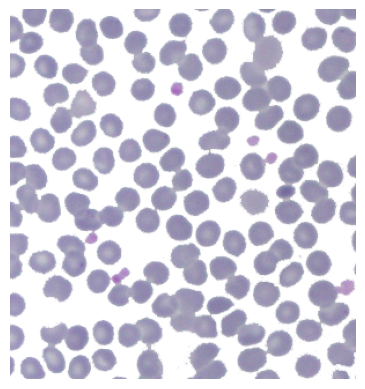


Phase-1 Score: 0.029
Anemia detected : NO

Phase-2 : Skipped

Final Assessment:
No anemia detected. RBC condition appears normal.

Final Assessment:
AI-based preliminary screening. Clinical confirmation required.


In [25]:
# ==========================
# CELL-2 : UPLOAD + PREDICT
# ==========================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.efficientnet import preprocess_input

print("Upload RBC Image")

uploaded = files.upload()

image_file = list(uploaded.keys())[0]

# --------------------------
# SETTINGS
# --------------------------
IMG = 224

# IMPORTANT FIX
phase1_threshold = 0.65

# use saved threshold for phase-2
# (already loaded in CELL-1)

# --------------------------
# PREPROCESS
# --------------------------
def preprocess(img_path):

    img = cv2.imread(img_path)

    img = cv2.resize(img, (IMG, IMG))

    img = img.astype(np.float32)

    img = preprocess_input(img)

    img = np.reshape(img, (1, IMG, IMG, 3))

    return img

# --------------------------
# DISPLAY IMAGE
# --------------------------
def show(img_path):

    img = cv2.cvtColor(
        cv2.imread(img_path),
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(img)

    plt.axis('off')

    plt.show()

# --------------------------
# MORPHOLOGY LOGIC
# --------------------------
def predict_morphology(score):

    if score > 0.85:

        return [
            "Microcytic RBCs",
            "Elliptocytes",
            "Target Cells"
        ]

    elif score > 0.70:

        return [
            "Microcytic RBCs",
            "Target Cells"
        ]

    elif score > 0.55:

        return [
            "Macrocytic RBCs",
            "Normocytic RBC variation"
        ]

    elif score > 0.40:

        return [
            "Mild RBC abnormality"
        ]

    else:

        return [
            "No major abnormal morphology"
        ]

# --------------------------
# DISEASE MAPPING
# --------------------------
def disease_mapping(morphology):

    diseases = set()

    if "Microcytic RBCs" in morphology:

        diseases.add(
            "Iron Deficiency Anemia"
        )

        diseases.add(
            "Thalassemia"
        )

    if "Elliptocytes" in morphology:

        diseases.add(
            "Hereditary Elliptocytosis"
        )

        diseases.add(
            "Iron Deficiency Anemia"
        )

    if "Target Cells" in morphology:

        diseases.add(
            "Thalassemia"
        )

        diseases.add(
            "Liver Disease"
        )

    if "Macrocytic RBCs" in morphology:

        diseases.add(
            "Vitamin B12 Deficiency"
        )

        diseases.add(
            "Folate Deficiency"
        )

    if "Normocytic RBC variation" in morphology:

        diseases.add(
            "Normocytic Anemia"
        )

    if "Mild RBC abnormality" in morphology:

        diseases.add(
            "Possible Early-stage Anemia"
        )

    if "No major abnormal morphology" in morphology:

        diseases.add(
            "No major RBC disorder detected"
        )

    return list(diseases)

# --------------------------
# START REPORT
# --------------------------
print("\n=======================================")
print("AI RBC DIAGNOSTIC REPORT")
print("=======================================")

show(image_file)

img = preprocess(image_file)

# --------------------------
# PHASE-1
# --------------------------
p1 = float(
    phase1_model.predict(
        img,
        verbose=0
    )[0][0]
)

print("\nPhase-1 Score:", round(p1, 3))

if p1 > phase1_threshold:

    print("Anemia detected : YES")

    # --------------------------
    # PHASE-2
    # --------------------------
    p2 = float(
        phase2_model.predict(
            img,
            verbose=0
        )[0][0]
    )

    print("\nPhase-2 Score:", round(p2, 3))

    if p2 > phase2_threshold:

        print("RBC abnormality : YES")

    else:

        print("RBC abnormality : NO")

    # --------------------------
    # MORPHOLOGY
    # --------------------------
    morphologies = predict_morphology(p2)

    print("\nDetected Morphology:")

    for m in morphologies:

        print("•", m)

    # --------------------------
    # DISEASES
    # --------------------------
    diseases = disease_mapping(morphologies)

    print("\nPossible Diseases:")

    for d in diseases:

        print("•", d)

    # --------------------------
    # CONFIDENCE
    # --------------------------
    print("\nModel Confidence:")

    print(
        "Anemia probability:",
        round(p1 * 100, 2),
        "%"
    )

    print(
        "Abnormal probability:",
        round(p2 * 100, 2),
        "%"
    )

else:

    print("Anemia detected : NO")

    print("\nPhase-2 : Skipped")

    print("\nFinal Assessment:")

    print(
        "No anemia detected. RBC condition appears normal."
    )

# --------------------------
# FINAL OUTPUT
# --------------------------
print("\nFinal Assessment:")

print(
    "AI-based preliminary screening. Clinical confirmation required."
)

print("=======================================")

unseen healthy

Upload RBC Image


Saving unseen-healthy.jpg to unseen-healthy (3).jpg

AI RBC DIAGNOSTIC REPORT


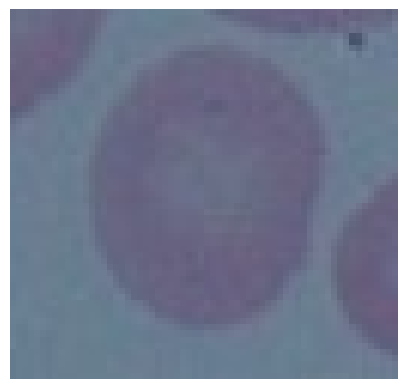


Phase-1 Score: 0.605
Anemia detected : NO

Phase-2 : Skipped

Final Assessment:
No anemia detected. RBC condition appears normal.

Final Assessment:
AI-based preliminary screening. Clinical confirmation required.


In [23]:
# ==========================
# CELL-2 : UPLOAD + PREDICT
# ==========================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.efficientnet import preprocess_input

print("Upload RBC Image")

uploaded = files.upload()

image_file = list(uploaded.keys())[0]

# --------------------------
# SETTINGS
# --------------------------
IMG = 224

# IMPORTANT FIX
phase1_threshold = 0.65

# use saved threshold for phase-2
# (already loaded in CELL-1)

# --------------------------
# PREPROCESS
# --------------------------
def preprocess(img_path):

    img = cv2.imread(img_path)

    img = cv2.resize(img, (IMG, IMG))

    img = img.astype(np.float32)

    img = preprocess_input(img)

    img = np.reshape(img, (1, IMG, IMG, 3))

    return img

# --------------------------
# DISPLAY IMAGE
# --------------------------
def show(img_path):

    img = cv2.cvtColor(
        cv2.imread(img_path),
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(img)

    plt.axis('off')

    plt.show()

# --------------------------
# MORPHOLOGY LOGIC
# --------------------------
def predict_morphology(score):

    if score > 0.85:

        return [
            "Microcytic RBCs",
            "Elliptocytes",
            "Target Cells"
        ]

    elif score > 0.70:

        return [
            "Microcytic RBCs",
            "Target Cells"
        ]

    elif score > 0.55:

        return [
            "Macrocytic RBCs",
            "Normocytic RBC variation"
        ]

    elif score > 0.40:

        return [
            "Mild RBC abnormality"
        ]

    else:

        return [
            "No major abnormal morphology"
        ]

# --------------------------
# DISEASE MAPPING
# --------------------------
def disease_mapping(morphology):

    diseases = set()

    if "Microcytic RBCs" in morphology:

        diseases.add(
            "Iron Deficiency Anemia"
        )

        diseases.add(
            "Thalassemia"
        )

    if "Elliptocytes" in morphology:

        diseases.add(
            "Hereditary Elliptocytosis"
        )

        diseases.add(
            "Iron Deficiency Anemia"
        )

    if "Target Cells" in morphology:

        diseases.add(
            "Thalassemia"
        )

        diseases.add(
            "Liver Disease"
        )

    if "Macrocytic RBCs" in morphology:

        diseases.add(
            "Vitamin B12 Deficiency"
        )

        diseases.add(
            "Folate Deficiency"
        )

    if "Normocytic RBC variation" in morphology:

        diseases.add(
            "Normocytic Anemia"
        )

    if "Mild RBC abnormality" in morphology:

        diseases.add(
            "Possible Early-stage Anemia"
        )

    if "No major abnormal morphology" in morphology:

        diseases.add(
            "No major RBC disorder detected"
        )

    return list(diseases)

# --------------------------
# START REPORT
# --------------------------
print("\n=======================================")
print("AI RBC DIAGNOSTIC REPORT")
print("=======================================")

show(image_file)

img = preprocess(image_file)

# --------------------------
# PHASE-1
# --------------------------
p1 = float(
    phase1_model.predict(
        img,
        verbose=0
    )[0][0]
)

print("\nPhase-1 Score:", round(p1, 3))

if p1 > phase1_threshold:

    print("Anemia detected : YES")

    # --------------------------
    # PHASE-2
    # --------------------------
    p2 = float(
        phase2_model.predict(
            img,
            verbose=0
        )[0][0]
    )

    print("\nPhase-2 Score:", round(p2, 3))

    if p2 > phase2_threshold:

        print("RBC abnormality : YES")

    else:

        print("RBC abnormality : NO")

    # --------------------------
    # MORPHOLOGY
    # --------------------------
    morphologies = predict_morphology(p2)

    print("\nDetected Morphology:")

    for m in morphologies:

        print("•", m)

    # --------------------------
    # DISEASES
    # --------------------------
    diseases = disease_mapping(morphologies)

    print("\nPossible Diseases:")

    for d in diseases:

        print("•", d)

    # --------------------------
    # CONFIDENCE
    # --------------------------
    print("\nModel Confidence:")

    print(
        "Anemia probability:",
        round(p1 * 100, 2),
        "%"
    )

    print(
        "Abnormal probability:",
        round(p2 * 100, 2),
        "%"
    )

else:

    print("Anemia detected : NO")

    print("\nPhase-2 : Skipped")

    print("\nFinal Assessment:")

    print(
        "No anemia detected. RBC condition appears normal."
    )

# --------------------------
# FINAL OUTPUT
# --------------------------
print("\nFinal Assessment:")

print(
    "AI-based preliminary screening. Clinical confirmation required."
)

print("=======================================")

unseen anemic

Upload RBC Image


Saving Thalassemia_4.JPG to Thalassemia_4 (2).JPG

AI RBC DIAGNOSTIC REPORT


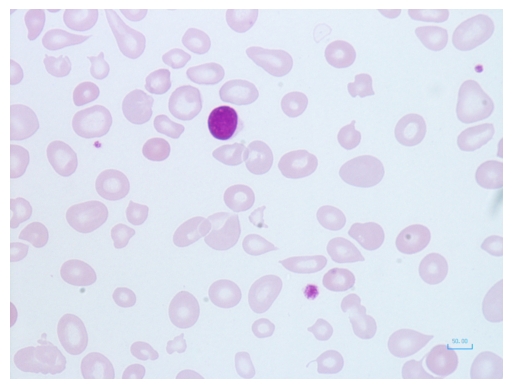


Phase-1 Score: 0.973
Anemia detected : YES

Phase-2 Score: 0.997
RBC abnormality : YES

Detected Morphology:
• Microcytic RBCs
• Elliptocytes
• Target Cells

Possible Diseases:
• Thalassemia
• Iron Deficiency Anemia
• Hereditary Elliptocytosis
• Liver Disease

Model Confidence:
Anemia probability: 97.34 %
Abnormal probability: 99.67 %

Final Assessment:
AI-based preliminary screening. Clinical confirmation required.


In [24]:
# ==========================
# CELL-2 : UPLOAD + PREDICT
# ==========================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.efficientnet import preprocess_input

print("Upload RBC Image")

uploaded = files.upload()

image_file = list(uploaded.keys())[0]

# --------------------------
# SETTINGS
# --------------------------
IMG = 224

# IMPORTANT FIX
phase1_threshold = 0.65

# use saved threshold for phase-2
# (already loaded in CELL-1)

# --------------------------
# PREPROCESS
# --------------------------
def preprocess(img_path):

    img = cv2.imread(img_path)

    img = cv2.resize(img, (IMG, IMG))

    img = img.astype(np.float32)

    img = preprocess_input(img)

    img = np.reshape(img, (1, IMG, IMG, 3))

    return img

# --------------------------
# DISPLAY IMAGE
# --------------------------
def show(img_path):

    img = cv2.cvtColor(
        cv2.imread(img_path),
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(img)

    plt.axis('off')

    plt.show()

# --------------------------
# MORPHOLOGY LOGIC
# --------------------------
def predict_morphology(score):

    if score > 0.85:

        return [
            "Microcytic RBCs",
            "Elliptocytes",
            "Target Cells"
        ]

    elif score > 0.70:

        return [
            "Microcytic RBCs",
            "Target Cells"
        ]

    elif score > 0.55:

        return [
            "Macrocytic RBCs",
            "Normocytic RBC variation"
        ]

    elif score > 0.40:

        return [
            "Mild RBC abnormality"
        ]

    else:

        return [
            "No major abnormal morphology"
        ]

# --------------------------
# DISEASE MAPPING
# --------------------------
def disease_mapping(morphology):

    diseases = set()

    if "Microcytic RBCs" in morphology:

        diseases.add(
            "Iron Deficiency Anemia"
        )

        diseases.add(
            "Thalassemia"
        )

    if "Elliptocytes" in morphology:

        diseases.add(
            "Hereditary Elliptocytosis"
        )

        diseases.add(
            "Iron Deficiency Anemia"
        )

    if "Target Cells" in morphology:

        diseases.add(
            "Thalassemia"
        )

        diseases.add(
            "Liver Disease"
        )

    if "Macrocytic RBCs" in morphology:

        diseases.add(
            "Vitamin B12 Deficiency"
        )

        diseases.add(
            "Folate Deficiency"
        )

    if "Normocytic RBC variation" in morphology:

        diseases.add(
            "Normocytic Anemia"
        )

    if "Mild RBC abnormality" in morphology:

        diseases.add(
            "Possible Early-stage Anemia"
        )

    if "No major abnormal morphology" in morphology:

        diseases.add(
            "No major RBC disorder detected"
        )

    return list(diseases)

# --------------------------
# START REPORT
# --------------------------
print("\n=======================================")
print("AI RBC DIAGNOSTIC REPORT")
print("=======================================")

show(image_file)

img = preprocess(image_file)

# --------------------------
# PHASE-1
# --------------------------
p1 = float(
    phase1_model.predict(
        img,
        verbose=0
    )[0][0]
)

print("\nPhase-1 Score:", round(p1, 3))

if p1 > phase1_threshold:

    print("Anemia detected : YES")

    # --------------------------
    # PHASE-2
    # --------------------------
    p2 = float(
        phase2_model.predict(
            img,
            verbose=0
        )[0][0]
    )

    print("\nPhase-2 Score:", round(p2, 3))

    if p2 > phase2_threshold:

        print("RBC abnormality : YES")

    else:

        print("RBC abnormality : NO")

    # --------------------------
    # MORPHOLOGY
    # --------------------------
    morphologies = predict_morphology(p2)

    print("\nDetected Morphology:")

    for m in morphologies:

        print("•", m)

    # --------------------------
    # DISEASES
    # --------------------------
    diseases = disease_mapping(morphologies)

    print("\nPossible Diseases:")

    for d in diseases:

        print("•", d)

    # --------------------------
    # CONFIDENCE
    # --------------------------
    print("\nModel Confidence:")

    print(
        "Anemia probability:",
        round(p1 * 100, 2),
        "%"
    )

    print(
        "Abnormal probability:",
        round(p2 * 100, 2),
        "%"
    )

else:

    print("Anemia detected : NO")

    print("\nPhase-2 : Skipped")

    print("\nFinal Assessment:")

    print(
        "No anemia detected. RBC condition appears normal."
    )

# --------------------------
# FINAL OUTPUT
# --------------------------
print("\nFinal Assessment:")

print(
    "AI-based preliminary screening. Clinical confirmation required."
)

print("=======================================")